# **№1**

Cначала выполним подготовку, выгрузим данные из таблички:

In [ ]:
import gdown
import pandas as pd
import numpy as np
view_url = "https://docs.google.com/spreadsheets/d/1mB9QSuJqu5gkpm4wkSs0x0Z3C1S4L1he/edit?gid=631003670#gid=631003670"
file_id = "1mB9QSuJqu5gkpm4wkSs0x0Z3C1S4L1he"
download_url = f"https://drive.google.com/uc?id={file_id}"
try:
    gdown.download(download_url, "data_penalty_results.xlsx", fuzzy=True)
    print("\nФайл успешно скачан!")
    xls = pd.ExcelFile("data_penalty_results.xlsx")
    print(f"Листы в файле: {xls.sheet_names}")
    players_data = {}
    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name)
        players_data[sheet_name] = df
        print(f"{sheet_name}: {len(df)} записей")

except Exception as e:
    print(f"Ошибка при скачивании: {e}")

Downloading...
From: https://drive.google.com/uc?id=1mB9QSuJqu5gkpm4wkSs0x0Z3C1S4L1he
To: /content/data_penalty_results.xlsx
100%|██████████| 49.4k/49.4k [00:00<00:00, 42.9MB/s]



Файл успешно скачан!
Листы в файле: ['Dennis Kolos', 'Ilya Tikhonov', 'Boris Saveliev', 'Yurii Ivanov', 'Yan Nay']
Dennis Kolos: 500 записей
Ilya Tikhonov: 500 записей
Boris Saveliev: 500 записей
Yurii Ivanov: 500 записей
Yan Nay: 500 записей


Отлично, теперь перейдем к выполнению задания:

Пункт а)

In [ ]:
def calculate_payoff_matrix(df):
    payoff_matrix = np.zeros((2, 2))
    counts_matrix = np.zeros((2, 2))
    action_map = {'L': 0, 'R': 1}
    for _, row in df.iterrows():
        i = action_map[row['penalty taker action']]
        j = action_map[row['goalkeeper action']]
        payoff_matrix[i, j] += row['result']
        counts_matrix[i, j] += 1
    for i in range(2):
        for j in range(2):
            payoff_matrix[i, j] = payoff_matrix[i, j] / counts_matrix[i, j]
    return payoff_matrix, counts_matrix

print("ПУНКТ (a): МАТРИЦЫ ВЫИГРЫШЕЙ ДЛЯ КАЖДОГО ПЕНАЛЬТИСТА \n\n")

payoff_matrices = {}
counts_matrices = {}
for player, df in players_data.items():
    payoff_matrix, counts_matrix = calculate_payoff_matrix(df)
    payoff_matrices[player] = payoff_matrix
    counts_matrices[player] = counts_matrix

    print(f"\nИГРОК: {player}")
    print("Матрица выигрышей, значение - вероятность гола, число в скобках - количество соотвествующих ситуаций - (L, L), (R, L) и т.д. :")
    print("\n           Вратарь: L                       R")
    actions = ['L', 'R']
    for i, action_t in enumerate(actions):
        row_str = f"Игрок {action_t}: "
        for j, action_g in enumerate(actions):
            prob = payoff_matrix[i, j]
            count = counts_matrix[i, j]
            row_str += f"   [{prob:.3f} {1-prob:.3f}] ({int(count):3d})  "
        print(row_str)

    total_goals = df['result'].sum()
    total_shots = len(df)
    success_rate = total_goals / total_shots
    print(f"\nИгрок забил {total_goals} голов из {total_shots} ударов")
    print(f"Вероятность гола: {success_rate:.3f}")
    print("\n\n")


ПУНКТ (a): МАТРИЦЫ ВЫИГРЫШЕЙ ДЛЯ КАЖДОГО ПЕНАЛЬТИСТА 



ИГРОК: Dennis Kolos
Матрица выигрышей, значение - вероятность гола, число в скобках - количество соотвествующих ситуаций - (L, L), (R, L) и т.д. :

           Вратарь: L                       R
Игрок L:    [0.190 0.810] (100)     [0.630 0.370] (100)  
Игрок R:    [0.910 0.090] (100)     [0.160 0.840] (200)  

Игрок забил 205 голов из 500 ударов
Вероятность гола: 0.410




ИГРОК: Ilya Tikhonov
Матрица выигрышей, значение - вероятность гола, число в скобках - количество соотвествующих ситуаций - (L, L), (R, L) и т.д. :

           Вратарь: L                       R
Игрок L:    [0.070 0.930] (100)     [0.790 0.210] (100)  
Игрок R:    [0.830 0.170] (100)     [0.160 0.840] (200)  

Игрок забил 201 голов из 500 ударов
Вероятность гола: 0.402




ИГРОК: Boris Saveliev
Матрица выигрышей, значение - вероятность гола, число в скобках - количество соотвествующих ситуаций - (L, L), (R, L) и т.д. :

           Вратарь: L                     

Пункт b)

Комментарии по решению буду писать прямо в коде, чтобы вам было проще отследить логику выполнения задания

In [ ]:
print("ПУНКТ (b): ВЫБОР ДВУХ ИГРОКОВ И АНАЛИЗ РАВНОВЕСИЙ НЭША\n")
selected_players = ['Dennis Kolos', 'Ilya Tikhonov']
print(f"Выбранные игроки: {selected_players}")

def find_nash_equilibria(payoff_matrix, player_name):
    actions = ['L', 'R']
    for i, action_t in enumerate(actions):
        for j, action_g in enumerate(actions):
            prob = payoff_matrix[i, j]
    goalkeeper_matrix = 1 - payoff_matrix
    for i, action_t in enumerate(actions):
        for j, action_g in enumerate(actions):
            prob = goalkeeper_matrix[i, j]
    pure_equilibria = []
    #Чистыми стратегиями будут те варианты, при которых никто из игроков не захочет отклоняться
    #Для этого будем смотреть по каждому варианту есть ли лучший ответ при фиксированном выборе одного из игроков
    for i_player in range(2):
        for j_keeper in range(2):
            is_equilibrium = True
            for i_alt in range(2):
                if payoff_matrix[i_alt, j_keeper] > payoff_matrix[i_player, j_keeper]:
                    is_equilibrium = False
                    #Нашли ответ лучше => страгегия не может быть равновесной
                    break
            #Если для пенальтиста выбор не меняется, то надо проверить вратаря:
            if is_equilibrium:
                for j_alt in range(2):
                    if goalkeeper_matrix[i_player, j_alt] > goalkeeper_matrix[i_player, j_keeper]:
                        is_equilibrium = False
                        #Нашли ответ лучше => страгегия не может быть равновесной
                        break
            if is_equilibrium:
                pure_equilibria.append((i_player, j_keeper))
    # Для пенальтиста: вероятность p удара влево, (1-p) вправо
    # Для вратаря: вероятность q прыжка влево, (1-q) вправо
    # В равновесии смешанных стратегий каждый игрок безразличен к действиям другого
    # Пенальтист безразличен между L и R, когда:
    # q * U(L,L) + (1-q) * U(L,R) = q * U(R,L) + (1-q) * U(R,R)
    # U_LL, U_LR, U_RL, U_RR = payoff_matrix[0,0], payoff_matrix[0,1], payoff_matrix[1,0], payoff_matrix[1,1]
    U_LL, U_LR = payoff_matrix[0, 0], payoff_matrix[0, 1]
    U_RL, U_RR = payoff_matrix[1, 0], payoff_matrix[1, 1]
    # Для пенальтиста: находит q* такое, что ожидаемый выигрыш от L = ожидаемому выигрышу от R
    # q * U_LL + (1-q) * U_LR = q * U_RL + (1-q) * U_RR
    # q*(U_LL - U_LR - U_RL + U_RR) = U_RR - U_LR
    # q* = (U_RR - U_LR) / (U_LL - U_LR - U_RL + U_RR)
    denominator = U_LL - U_LR - U_RL + U_RR
    if abs(denominator) > 1e-10:
        q_star = (U_RR - U_LR) / denominator
    else:
        q_star = 0.5
    # Для вратаря: находит p* такое, что ожидаемый выигрыш от L = ожидаемому выигрышу от R
    # Вратарь минимизирует голы, поэтому его выигрыши: 1 - U
    G_LL, G_LR = 1 - U_LL, 1 - U_LR
    G_RL, G_RR = 1 - U_RL, 1 - U_RR
    # p * G_LL + (1-p) * G_RL = p * G_LR + (1-p) * G_RR
    # p*(G_LL - G_RL - G_LR + G_RR) = G_RR - G_RL
    denominator_g = G_LL - G_RL - G_LR + G_RR
    if abs(denominator_g) > 1e-10:
        p_star = (G_RR - G_RL) / denominator_g
    else:
        p_star = 0.5
    expected_payoff_player = (p_star * q_star * U_LL +
                             p_star * (1-q_star) * U_LR +
                             (1-p_star) * q_star * U_RL +
                             (1-p_star) * (1-q_star) * U_RR)
    expected_payoff_keeper = 1 - expected_payoff_player
    return pure_equilibria, (p_star, q_star)
nash_results = {}
for player in selected_players:
    payoff_matrix = payoff_matrices[player]
    pure_eq, mixed_eq = find_nash_equilibria(payoff_matrix, player)
    nash_results[player] = {
        'pure_equilibria': pure_eq,
        'mixed_equilibrium': mixed_eq,
        'payoff_matrix': payoff_matrix
    }

print("\nОТВЕТ ДЛЯ ПУНКТА (b)")

for player in selected_players:
    print(f"\n{player}:")
    pure_eq = nash_results[player]['pure_equilibria']
    mixed_eq = nash_results[player]['mixed_equilibrium']
    if pure_eq:
        print(f"  Равновесия в чистых стратегиях: {len(pure_eq)}")
        for eq in pure_eq:
            actions = ['L', 'R']
            print(f"    - Игрок {actions[eq[0]]}, Вратарь {actions[eq[1]]}")
    else:
        print(f"  Равновесий в чистых стратегиях: нет")
    p_star, q_star = mixed_eq
    print(f"  Равновесие в смешанных стратегиях:")
    print(f"    Пенальтист: P(L) = {p_star:.3f}, P(R) = {1-p_star:.3f}")
    print(f"    Вратарь: P(L) = {q_star:.3f}, P(R) = {1-q_star:.3f}")

ПУНКТ (b): ВЫБОР ДВУХ ИГРОКОВ И АНАЛИЗ РАВНОВЕСИЙ НЭША

Выбранные игроки: ['Dennis Kolos', 'Ilya Tikhonov']

ОТВЕТ ДЛЯ ПУНКТА (b)

Dennis Kolos:
  Равновесий в чистых стратегиях: нет
  Равновесие в смешанных стратегиях:
    Пенальтист: P(L) = 0.630, P(R) = 0.370
    Вратарь: P(L) = 0.395, P(R) = 0.605

Ilya Tikhonov:
  Равновесий в чистых стратегиях: нет
  Равновесие в смешанных стратегиях:
    Пенальтист: P(L) = 0.482, P(R) = 0.518
    Вратарь: P(L) = 0.453, P(R) = 0.547


Пункт c)

Комментарии по решению буду писать прямо в коде, чтобы вам было проще отследить логику выполнения задания

In [ ]:
print("ПУНКТ (c): РЕКОМЕНДАЦИИ ДЛЯ ТРЕНЕРА КОМАНДЫ HEADS")
print("""
В пункте b) мы проанализировали двух игроков и нашли для них равновесия Нэша.
Теперь оценим, насколько текущая стратегия вратаря (50/50) близка к оптимальной
""")

def analyze_goalkeeper_recommendations(payoff_matrix, player_name, nash_results, current_q=0.5):
    print(f"\nАнализ для игрока: {player_name}")
    mixed_eq = nash_results[player_name]['mixed_equilibrium']
    p_star, q_star = mixed_eq
    U_LL, U_LR = payoff_matrix[0, 0], payoff_matrix[0, 1]
    U_RL, U_RR = payoff_matrix[1, 0], payoff_matrix[1, 1]

    # Найдем лучший ответ пенальтиста на текущую стратегию вратаря
    E_L_current = current_q * U_LL + (1-current_q) * U_LR
    E_R_current = current_q * U_RL + (1-current_q) * U_RR
    best_response_payoff = max(E_L_current, E_R_current)

    # Выигрыш вратаря при текущей стратегии
    goalkeeper_payoff_current = 1 - best_response_payoff

    # Посчитаем ожидаемые выигрыши пенальтиста и вратаря
    equilibrium_payoff_player = (p_star * q_star * U_LL +
                                p_star * (1-q_star) * U_LR +
                                (1-p_star) * q_star * U_RL +
                                (1-p_star) * (1-q_star) * U_RR)
    goalkeeper_payoff_optimal = 1 - equilibrium_payoff_player

    # Разница между оптимальным выбором и текущим
    improvement = goalkeeper_payoff_optimal - goalkeeper_payoff_current

    print("Используем результаты пункта (b):")
    print(f"  - Оптимальная стратегия вратаря: P(L) = {q_star:.3f}")
    print(f"                                   P(R) = {1 - q_star:.3f}")
    print(f"  - Оптимальная стратегия пенальтиста: P(L) = {p_star:.3f}")
    print(f"                                       P(R) = {1 - p_star:.3f}")
    print(f"  - Ожидаемый выигрыш пенальтиста в равновесии Нэша: {equilibrium_payoff_player:.3f}")

    print(f"\nАнализ текущей стратегии (P(L) = P(R) = 0.5):")
    if E_L_current > E_R_current:
        print(f"  - Пенальтист будет ВСЕГДА бить влево (E_L = {E_L_current:.3f} > E_R = {E_R_current:.3f})")
    elif E_R_current > E_L_current:
        print(f"  - Пенальтист будет ВСЕГДА бить вправо (E_R = {E_R_current:.3f} > E_L = {E_L_current:.3f})")
    else:
        print(f"  - Пенальтисту безразлично (E_L = E_R = {E_L_current:.3f})")

    print(f"  - Потенциальная вероятность гола: {best_response_payoff:.3f}")
    print(f"  - Текущий выигрыш вратаря: {goalkeeper_payoff_current:.3f}")

    print(f"\nСравнение с оптимальной стратегией:")
    print(f"  - Оптимальная вероятность гола: {equilibrium_payoff_player:.3f}")
    print(f"  - Оптимальный выигрыш вратаря: {goalkeeper_payoff_optimal:.3f}")
    print(f"  - Улучшение при оптимальной стратегии: +{improvement:.3f}")
    if abs(q_star - 0.5) < 0.05:
        optimality = "ХОРОШАЯ"
        reason = "оптимальная стратегия близка к 50/50"
    elif abs(q_star - 0.5) < 0.15:
        optimality = "УМЕРЕННАЯ"
        reason = "есть умеренные отличия от 50/50"
    else:
        optimality = "НИЗКАЯ"
        reason = "сильное отклонение от оптимальной стратегии"
    print(f"\nОценка текущей стратегии: {optimality}")
    print(f"  Причина: {reason}")
    if improvement > 0.15:
        recommendation = "СТОИТ ИЗМЕНИТЬ СТРАТЕГИЮ"
        rec_type = "URGENT"
    elif improvement > 0.05:
        recommendation = "МОЖНО РАССМОТРЕТЬ ИЗМЕНЕНИЕ СТРАТЕГИИ"
        rec_type = "CONSIDER"
    else:
        recommendation = "ТЕКУЩАЯ СТРАТЕГИЯ ХОРОША"
        rec_type = "KEEP"

    print(f"Рекомендация: {recommendation}")
    if rec_type == "URGENT":
        print(f"Действие: Использовать P(L) = {q_star:.2f} вместо 0.5")
    elif rec_type == "CONSIDER":
        print(f"Действие: Рассмотреть P(L) = {q_star:.2f} для этого игрока")
    else:
        print(f"Действие: Сохранить 50/50 стратегию")

    return {
        'player': player_name,
        'optimal_q': q_star,
        'current_goalkeeper_payoff': goalkeeper_payoff_current,
        'optimal_goalkeeper_payoff': goalkeeper_payoff_optimal,
        'improvement': improvement,
        'optimality': optimality,
        'recommendation': rec_type
    }
recommendations = []
for player in selected_players:
    payoff_matrix = payoff_matrices[player]
    result = analyze_goalkeeper_recommendations(payoff_matrix, player, nash_results)
    recommendations.append(result)

total_improvement = sum(r['improvement'] for r in recommendations)
avg_improvement = total_improvement / len(recommendations)

urgent_count = sum(1 for r in recommendations if r['recommendation'] == "URGENT")
consider_count = sum(1 for r in recommendations if r['recommendation'] == "CONSIDER")
keep_count = sum(1 for r in recommendations if r['recommendation'] == "KEEP")
print(f"\nОтвет:")
if urgent_count >= 1:
    print("""
РЕКОМЕНДУЮ: ВНЕДРИТЬ АДАПТИВНУЮ СТРАТЕГИЮ

ОБОСНОВАНИЕ:
• Для некоторых игроков оптимальная стратегия отличается от 50/50
• Текущая стратегия позволяет противникам эксплуатировать предсказуемость
• Можно снизить вероятность гола на {avg_improvement:.3f} в среднем

ПРАКТИЧЕСКИЕ ШАГИ:
1. Для каждого игрока использовать свою оптимальную стратегию из анализа
2. Разработать простую систему напоминаний для вратаря
3. Начать с 2-3 основных пенальтистов команды Tales
""")
elif consider_count >= 1:
    print("""
РЕКОМЕНДУЮ: ПОСТЕПЕННАЯ АДАПТАЦИЯ СТРАТЕГИИ

ОБОСНОВАНИЕ:
• Есть умеренный потенциал для улучшения
• Можно начать с адаптации против ключевых игроков
• Сохранить простоту для остальных случаев

ПРАКТИЧЕСКИЕ ШАГИ:
1. Внедрить адаптацию только против основных пенальтистов
2. Сохранить 50/50 против остальных игроков
3. Оценить эффективность через несколько матчей
""")
else:
    print("""
РЕКОМЕНДУЮ: СОХРАНИТЬ ТЕКУЩУЮ СТРАТЕГИЮ 50/50

ОБОСНОВАНИЕ:
• Оптимальные стратегии близки к 50/50 для всех игроков
• Выигрыш от изменений незначителен
• Простота текущей стратегии - это преимущество

ДОПОЛНИТЕЛЬНО:
• Продолжать сбор статистики
• Периодически пересчитывать оптимальные стратегии
""")

ПУНКТ (c): РЕКОМЕНДАЦИИ ДЛЯ ТРЕНЕРА КОМАНДЫ HEADS

В пункте b) мы проанализировали двух игроков и нашли для них равновесия Нэша.
Теперь оценим, насколько текущая стратегия вратаря (50/50) близка к оптимальной


Анализ для игрока: Dennis Kolos
Используем результаты пункта (b):
  - Оптимальная стратегия вратаря: P(L) = 0.395
                                   P(R) = 0.605
  - Оптимальная стратегия пенальтиста: P(L) = 0.630
                                       P(R) = 0.370
  - Ожидаемый выигрыш пенальтиста в равновесии Нэша: 0.456

Анализ текущей стратегии (P(L) = P(R) = 0.5):
  - Пенальтист будет ВСЕГДА бить вправо (E_R = 0.535 > E_L = 0.410)
  - Потенциальная вероятность гола: 0.535
  - Текущий выигрыш вратаря: 0.465

Сравнение с оптимальной стратегией:
  - Оптимальная вероятность гола: 0.456
  - Оптимальный выигрыш вратаря: 0.544
  - Улучшение при оптимальной стратегии: +0.079

Оценка текущей стратегии: УМЕРЕННАЯ
  Причина: есть умеренные отличия от 50/50
Рекомендация: МОЖНО РАССМОТР

Несмотря на не маленькое количество информации в выводе, стоит посмотреть код целиком, потому что в нем более подробные комментарии относительно разных случаев

Подводя общий итог, если в команде противника много игроков, для которых при сравнении текущей стретегии и равновесной возникает сильная разница не в пользу текущей, стоит поменять стратегию на лучший вариант. Если разница не столь высока - то можно оставить и текущую стратегию, существенно изменение ничего не улучшит. Для анализа можно выбрать хоть всех пятерых футболистов, в таком случае картина для тренера будет ещё более подробная, но в задании это не просят. Я делал выводы исходя из данных о двух пенальтистах, которые получил ранее в пункте б), использовал их как основу для анализа, как и попросили в задании.

# **№2**

In [ ]:
import gdown
import pandas as pd
import numpy as np
file_id = "1wPvSb7zs7RiFgu3EKjgm37pB7oo4G01m"
download_url = f"https://drive.google.com/uc?id={file_id}"
print("-"*30)
print("ща чета скачается")
print("-"*30)
try:
    gdown.download(download_url, "data_payoff_matrix.xlsx", fuzzy=True)
    xls = pd.ExcelFile("data_payoff_matrix.xlsx")
    players_data = {}
    for sheet_name in xls.sheet_names:
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)
        df = df.apply(pd.to_numeric, errors='coerce')
        df = df.dropna(axis=0, how='all').dropna(axis=1, how='all')
        df = df.fillna(0)
        players_data[sheet_name] = df
    sheets = list(players_data.keys())
    print("\n" + "-"*30)
    print("чета скачалось")
    print("-"*30)
    A = players_data[sheets[0]].to_numpy(dtype=float)
    B = players_data[sheets[1]].to_numpy(dtype=float)
    m, n = A.shape
    equilibria = []
    for i in range(m):
        for j in range(n):
            # Проверяем условие лучшего ответа для обоих игроков
            cond1 = A[i, j] == np.max(A[:, j])# 1-й игрок
            cond2 = B[i, j] == np.max(B[i, :])# 2-й игрок
            if cond1 and cond2:
                equilibria.append((i + 1, j + 1))
    if equilibria:
        print("\n\n\nРавновесия по Нэшу в чистых стратегиях найдены:")
        for eq in equilibria:
            i, j = eq
            print(f"Стратегия a{i}, b{j} "
                  f"(Выигрыши: A={A[i-1, j-1]}, B={B[i-1, j-1]})")
    else:
        print("\nРавновесий по Нэшу в чистых стратегиях нет")

except Exception as e:
    print(f"Ошибка при скачивании или обработке: {e}")



------------------------------
ща чета скачается
------------------------------


Downloading...
From: https://drive.google.com/uc?id=1wPvSb7zs7RiFgu3EKjgm37pB7oo4G01m
To: /content/data_payoff_matrix.xlsx
100%|██████████| 18.4k/18.4k [00:00<00:00, 26.5MB/s]



------------------------------
чета скачалось
------------------------------



Равновесия по Нэшу в чистых стратегиях найдены:
Стратегия a7, b17 (Выигрыши: A=78.0, B=94.0)
Стратегия a10, b13 (Выигрыши: A=98.0, B=98.0)


# **№3**

# **Описание примера**
Пират захватил пленного, у пленного есть важная для пирата информация (скажем о пути, по которому будет проходить судно с нужным пирату товаром). Пират угрожает: "Если ты не скажешь - я скину тебя голодным акулам".


///// Игроки:

игрок P (Pirate) - пират, который хочет получить информацию,
игрок C (Captive) - пленник, у которого есть информация, нужная пирату


///// Ход игры:

Это последовательная динамическая игра, сначала пленному C нужно выбрать - сказать или не сказать. Если сказал - игра заканчивается, пират получил информацию. Если не сказал - тогда пират решает: скинуть пленника за борт или оставить живым (пощадить)

///// Выигрыши:

1) Если C скажет:

*   Выигрыш P = +10
*   Выиграш C = -50 (за раскрытие тайны последует наказание на свободе)
2) Если С не скажет:
    - Далее выбор P:
        1) Если P скинет пленного:
            * Выигрыш P = 0 (информации нет, пленного тоже нет)
            * Выиграш C = -100 (смерть)
        2) Если P пощадит:
            * Выигрыш P = 2 (есть шанс, что он еще сможет получить хоть какую-то полезную информацию, может частично)
            * Выигрыш C = -20 (остается жив, но в плену)
        
///// Решение игры:

Решаем начиная с выбора пирата:
* Вариант скинуть дает payoff = 0
* Вариант пощадить дает payoff = 2

Рациональный пират выберет вариант пощадить, так как 2 > 0

Теперь пленный прогнозирует:
* Если пленный скажет, то его payoff = -50
* Если не скажет и заетм пират его пощадит, его payoff = -20
Рациональный пленный предпочтет не сказать, так как -20 > -50

** - вариант "пощадить" для P подразумевает, что C останется в плену

///// Итог:

Пленный не скажет информацию и пират его пощадит.
Это SPNE

Угроза non-credible потому что она направлена на то, чтобы изменить выбор пленного, заставить его сказать информацию, но в случае реального выбора, эта угроза становится невыгодной для самого пирата, ведь убив пленного он окончательно потеряет доступ к информации, из-за этого пленный не верит в угрозу

Пример валиден, поскольку в реальном мире до сих пор есть пираты (например в Африке, но это современные пираты, не стоит представлять джека воробья или что-то в этом роде), поэтому описанная ситуация вполне реалистична

///// Как игроки могут сделать угрозу достоверной

Так как в задании не уточняются ограничения, то надеюсь, что такой вариант подойдет:

Все прошлые условия и ход игры кроме некоторых выигрышей сохраним

Введем обозначния - UP_S = выигрыш P при том, что C скажет информацию (S = skazal)

UP_(N, K) - выигрыш P если C не скажет, а P скинет C (N = Ne skazal, K = kill)

UP_(N, L) - выигрыш P если С не скажет, а P пощадит (L = leave alive)

UP_S и UP_(N, K) оставим неизменными

UP_(N, L) = (1-p)LP + p(L-D) = LP - p*D
где p = вероятность, с которой C захочет отомстить пирату за пленение, D - ущерб пирату от мести пленного и LP - прошлая выгода пирата от пощады

Условие, при котором угроза станет достоверной -
UP_(N, K) > UP_(N, L) <=> UP_(N, K) > LP - p*D

Используем прошлые параметры: UP_(N, K) = 0, LP = 2, тогда решим неравенство 0 > 2 - pD, пусть D = 20, а p = 0.2, тогда 0 > 2 - 4 => 0 > -2 => условие выполняется, тогда новый UP_(N, L) = -2

В таком случае пирату уже не выгодно оставлять в живых пленного, пират выберет скинуть пленного, ведь теперь его выгода от этого решения больше (0 > -2)

В таком случае угроза становится credible



/////////

Дерево для игры с non-credible угрозой

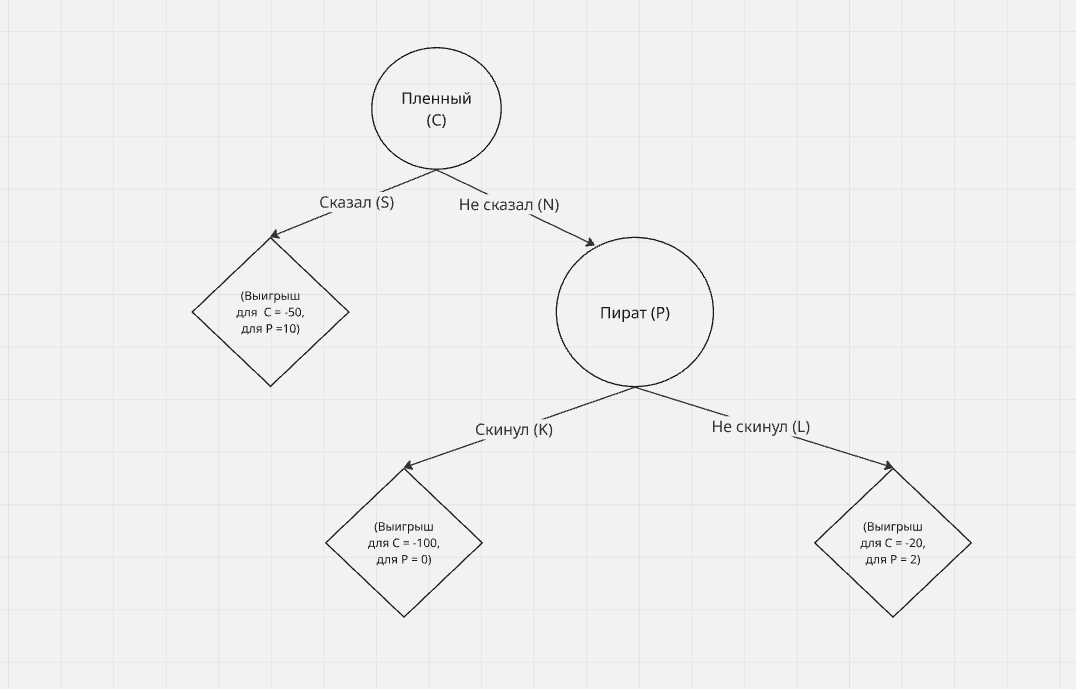



Дерево для игры с credible угрозой

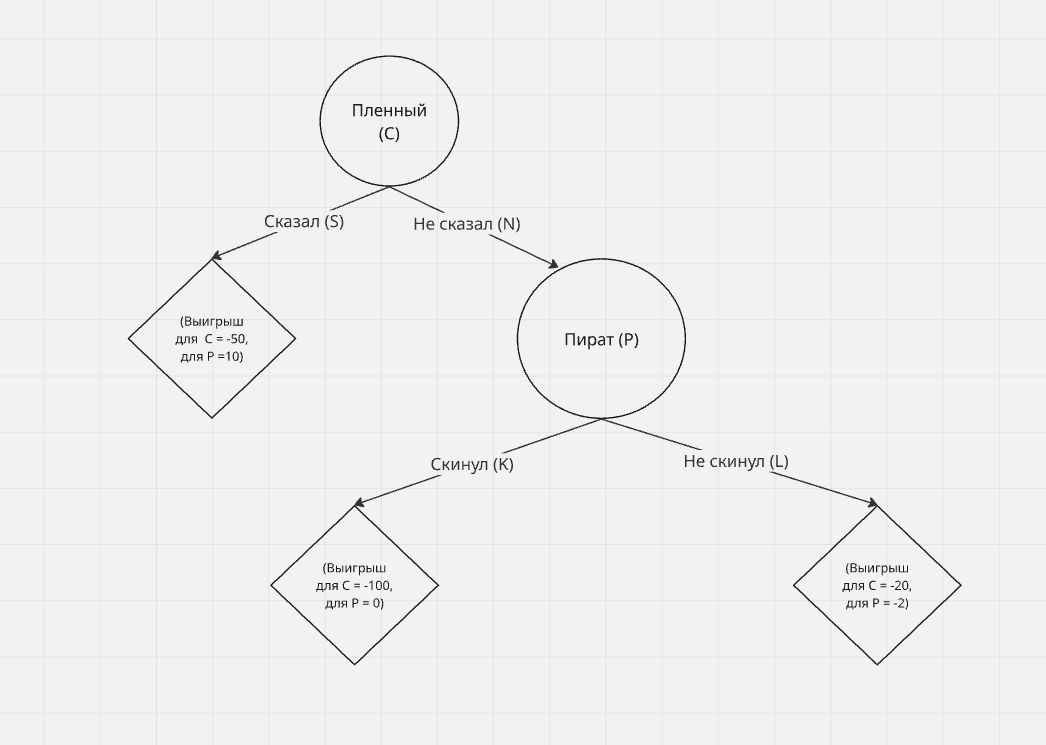